# 00 — The Gray-Scott Solver & Phase-Space EDA

This notebook is the foundation of the whole project. Before any neural network exists,
we need a trustworthy **ground-truth solver**, and we need to look — with our own eyes —
at what it actually produces across parameter space. Every later validation claim
("the surrogate matches the solver", "the recovered (F, k) lands in the right regime")
is a comparison against what we establish here. If this notebook is wrong, everything
downstream is confidently wrong.

## The physics

Gray-Scott models two chemicals, U and V, diffusing and reacting on a 2D grid:

$$
\frac{\partial U}{\partial t} = D_u \nabla^2 U - UV^2 + F(1-U)
$$
$$
\frac{\partial V}{\partial t} = D_v \nabla^2 V + UV^2 - (F+k)V
$$

Reading each term:
- **Diffusion** ($D_u \nabla^2 U$, $D_v \nabla^2 V$): both chemicals spread from where they're
  concentrated toward where they're sparse. $D_u > D_v$ — U spreads faster than V.
- **Reaction / autocatalysis** ($-UV^2$ / $+UV^2$): where U and V meet, V consumes U to make
  more of itself (one U plus two V becomes three V). This is what fights diffusion's smoothing
  and creates structure.
- **Feed & kill** ($F(1-U)$ / $-(F+k)V$): fresh U is replenished everywhere at rate $F$; V is
  removed everywhere at rate $k$. Without this the system would either die out or blow up.

$\nabla^2$ (the Laplacian) is implemented as a 5-point stencil with **periodic** (wrap-around)
boundaries — this choice matters later: the neural surrogate's convolutions must wrap the same
way, or it learns the wrong edge physics.

Two equations, four constants ($D_u$, $D_v$, $F$, $k$). The remarkable fact this whole project
hinges on: **the character of the emergent pattern — spots, stripes, mazes, or nothing at all —
is controlled almost entirely by just two of those four numbers, $F$ and $k$.** That 2D
($F$, $k$) plane is the "phase space" this notebook maps out.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from graydiff.constants import DEFAULT_GRID_SIZE, F_RANGE, K_RANGE, MAZES_CHECKPOINT, SPOTS_CHECKPOINT
from graydiff.phase_classify import classify_pattern
from graydiff.solver import gray_scott_step, laplacian, random_seed, rollout, standard_seed

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.facecolor"] = "white"


## 1. Validating the Laplacian and the step function

Before trusting any output, confirm the primitive building block does what it should:
a single spike in an otherwise-zero field must produce $-4$ at its own location and
$+1$ at each of its four periodic neighbours (the definition of the 5-point stencil),
and the whole field must sum to exactly zero (a periodic Laplacian conserves total
"mass" — it only ever redistributes it).

In [2]:
Z = np.zeros((5, 5))
Z[2, 2] = 1.0
lap = laplacian(Z)
print("Laplacian of a single spike:")
print(lap)
print("\nCenter:", lap[2, 2], "(expect -4)")
print("Sum over the whole field:", lap.sum(), "(expect 0 — periodic Laplacian conserves mass)")

# And confirm periodic wrap: a spike in the corner should affect its wrapped neighbours too
Z2 = np.zeros((5, 5))
Z2[0, 0] = 1.0
lap2 = laplacian(Z2)
print("\nSpike at [0,0]; value at [4,0] (wrapped neighbour above row 0):", lap2[4, 0], "(expect 1)")

Laplacian of a single spike:
[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  1. -4.  1.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.]]

Center: -4.0 (expect -4)
Sum over the whole field: 0.0 (expect 0 — periodic Laplacian conserves mass)

Spike at [0,0]; value at [4,0] (wrapped neighbour above row 0): 1.0 (expect 1)


## 2. The two named checkpoints — ground-truthing the solver

The spec gives two specific $(F, k)$ points with known pattern types. If the solver is
implemented correctly, these two points **must** reproduce the named regimes. This is the
single most important check in this notebook — everything else builds on it.

One subtlety surfaced while building this: the "empty dish" state $(U, V) = (1, 0)$ is a
**linearly stable fixed point for every** $(F, k) > 0$ — the Jacobian of the reaction
kinetics there is diagonal with both eigenvalues negative ($-F$ and $-(F+k)$). So Gray-Scott
pattern formation is *not* a small-perturbation Turing instability that grows spontaneously
out of the uniform state; it requires a large-enough nucleating disturbance to kick the
system away from $(1,0)$ at all. Empirically (see `graydiff.solver._blob_plus_global_noise`),
a single central blob alone reliably nucleates the low-$F$ "maze" regime but lets the
high-$F$ "spot" regime decay straight back to $(1,0)$; domain-wide noise alone does the
reverse. The seed used everywhere in this project combines both.

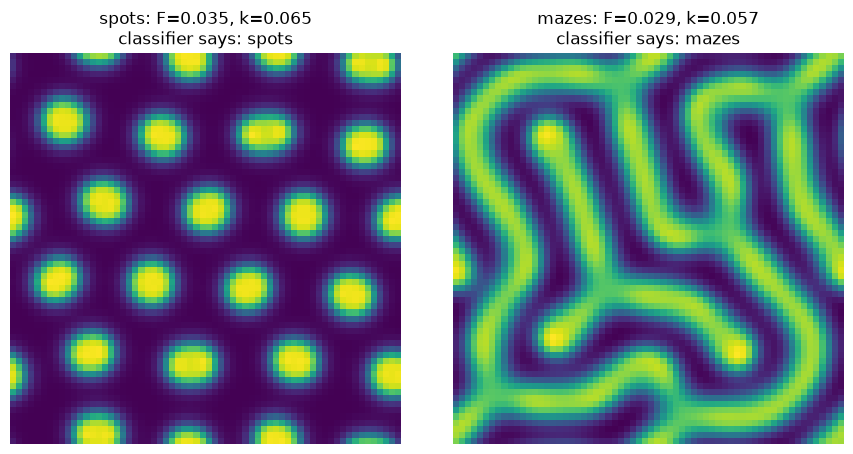

Both named checkpoints confirmed: the solver is producing the expected physics.


In [3]:
N_STEPS = 10_000
GRID = DEFAULT_GRID_SIZE

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (label, params) in zip(axes, [("spots", SPOTS_CHECKPOINT), ("mazes", MAZES_CHECKPOINT)]):
    U, V = standard_seed(GRID, GRID)
    Uf, Vf, _ = rollout(U, V, n_steps=N_STEPS, F=params["F"], k=params["k"])
    predicted = classify_pattern(Vf)
    ax.imshow(Vf, cmap="viridis")
    ax.set_title(f"{label}: F={params['F']}, k={params['k']}\nclassifier says: {predicted}")
    ax.axis("off")
    assert predicted == label, f"expected {label}, classifier said {predicted}"
plt.tight_layout()
plt.show()
print("Both named checkpoints confirmed: the solver is producing the expected physics.")

## 3. Mapping the full $(F, k)$ phase space

Now the real EDA: sweep a grid over the $(F, k)$ region this whole project operates in
(`F_RANGE`, `K_RANGE` from `graydiff.constants`), run the real solver at every point from
the same standard seed, and look at what comes out. This grid — both the visual thumbnails
and the classified regions — is the reference every later "does the surrogate learn the
right physics" claim gets compared against.

Rendered 100 thumbnails in 51.2s (512 ms/run)


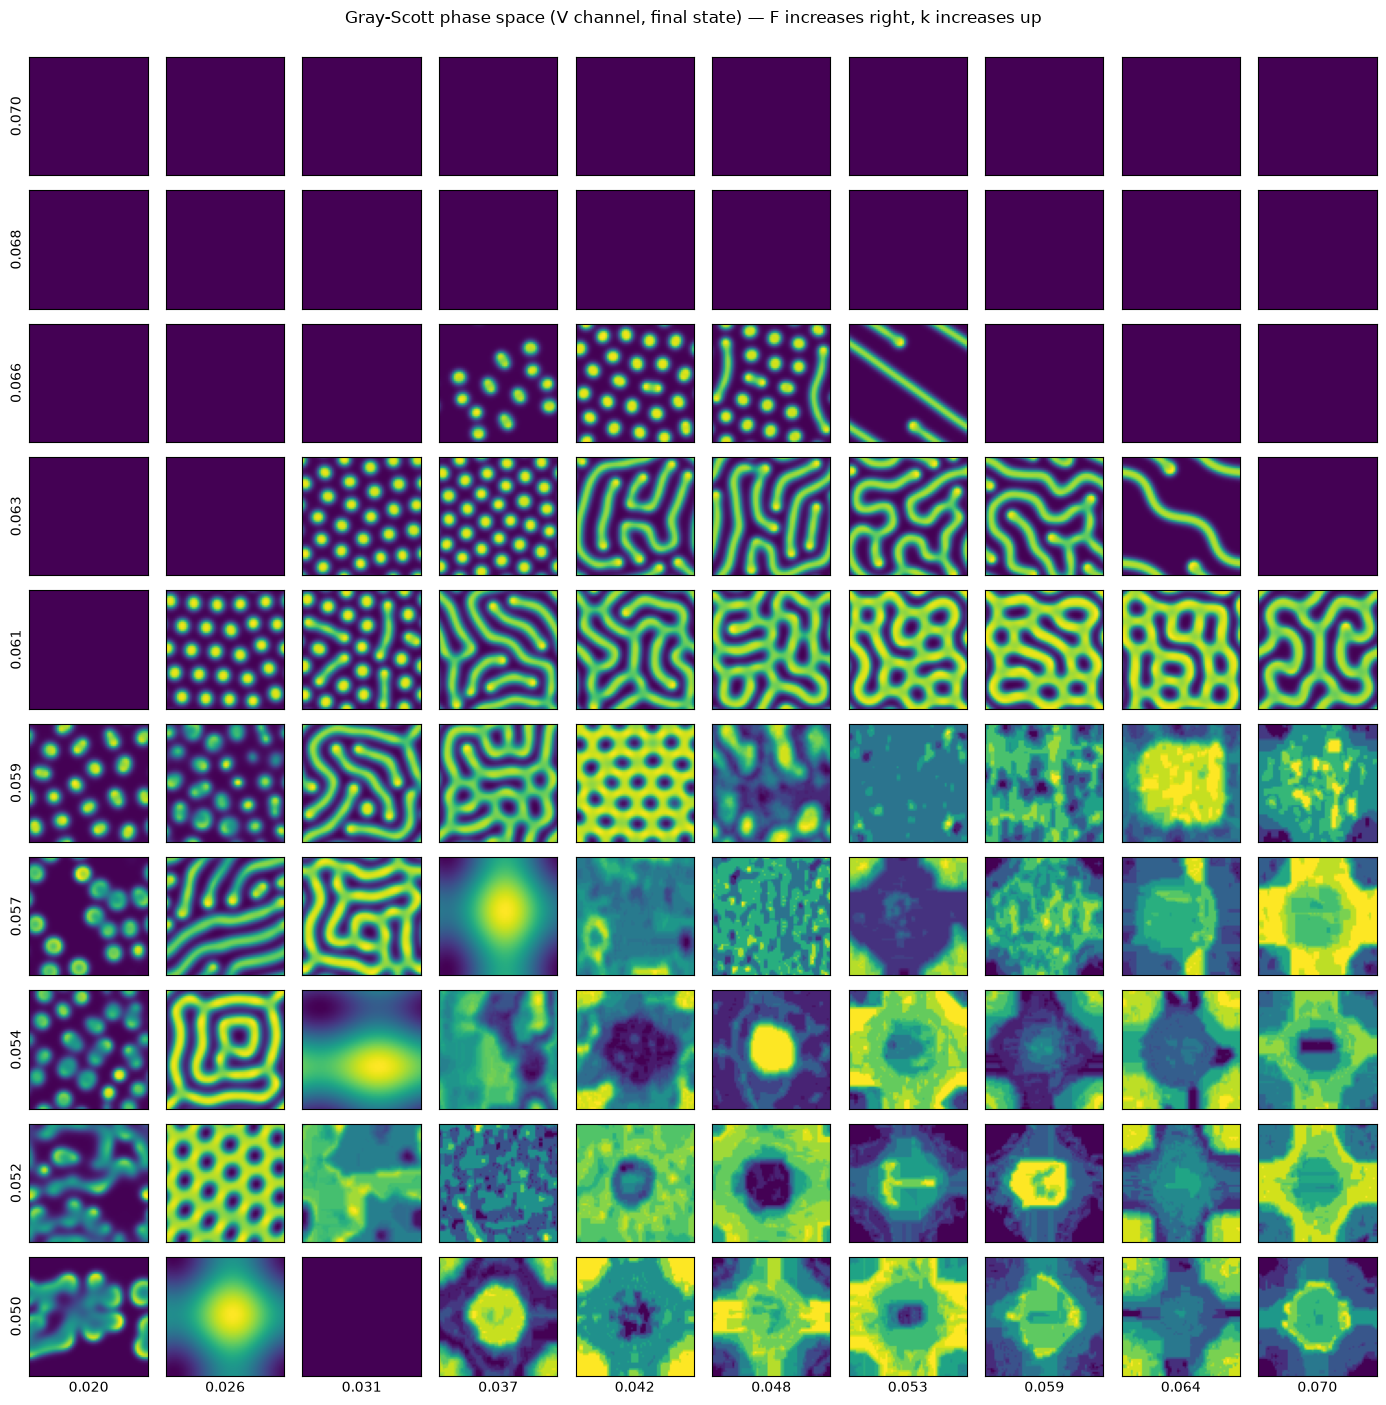

In [4]:
N_THUMB = 10  # thumbnail grid resolution — coarse enough to eyeball each cell
F_vals = np.linspace(*F_RANGE, N_THUMB)
k_vals = np.linspace(*K_RANGE, N_THUMB)

fig, axes = plt.subplots(N_THUMB, N_THUMB, figsize=(14, 14))
thumb_fields = {}
t0 = time.perf_counter()
for i, F in enumerate(F_vals):
    for j, k in enumerate(k_vals):
        U, V = standard_seed(GRID, GRID)
        _, Vf, _ = rollout(U, V, n_steps=N_STEPS, F=F, k=k)
        thumb_fields[(i, j)] = Vf
        ax = axes[N_THUMB - 1 - j, i]  # k increasing upward, F increasing rightward
        ax.imshow(Vf, cmap="viridis")
        ax.set_xticks([]); ax.set_yticks([])
t1 = time.perf_counter()
print(f"Rendered {N_THUMB*N_THUMB} thumbnails in {t1-t0:.1f}s ({(t1-t0)/(N_THUMB*N_THUMB)*1000:.0f} ms/run)")

for i, F in enumerate(F_vals):
    axes[N_THUMB - 1, i].set_xlabel(f"{F:.3f}")
for j, k in enumerate(k_vals):
    axes[N_THUMB - 1 - j, 0].set_ylabel(f"{k:.3f}")
fig.suptitle("Gray-Scott phase space (V channel, final state) — F increases right, k increases up", y=1.0)
plt.tight_layout()
plt.savefig("../figures/00_phase_diagram_thumbnails.png", dpi=110, bbox_inches="tight")
plt.show()

**What to look for by eye:** moving across this grid you should see the pattern character
shift — dense spot lattices in one region, winding maze/labyrinth structures in another,
possibly some banded stripe regions, and at the edges of the sampled range, fields that
have died back to the uniform "empty dish" or saturated to a uniform high-V state. This
qualitative shift, from just two numbers, is the entire reason the inverse-design problem
("which physics produced this pattern?") is well-posed at all — pattern type is a low-
dimensional function of $(F, k)$, not an arbitrary function of the full high-dimensional
field.

## 4. A finer, classified phase diagram

The thumbnail grid is for human eyes. For anything downstream that needs to *use* the phase
diagram programmatically (histogramming training-data coverage in notebook 01, checking the
surrogate lands in the right regime in notebook 04, drawing the background regions of the
web UI's phase-diagram view), we need a labeled grid — finer resolution, using the heuristic
classifier, cached to disk.

Classified 484 grid points in 255.4s


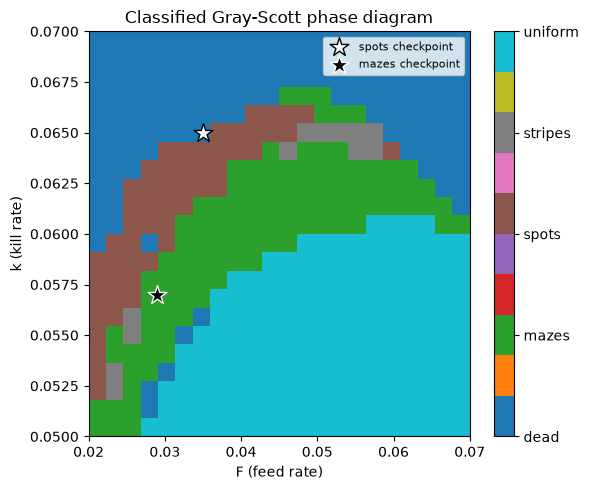


Label counts across the grid: Counter({'uniform': 175, 'dead': 142, 'mazes': 102, 'spots': 53, 'stripes': 12})


In [5]:
N_FINE = 22
F_fine = np.linspace(*F_RANGE, N_FINE)
k_fine = np.linspace(*K_RANGE, N_FINE)

label_grid = np.empty((N_FINE, N_FINE), dtype=object)
t0 = time.perf_counter()
for i, F in enumerate(F_fine):
    for j, k in enumerate(k_fine):
        U, V = standard_seed(GRID, GRID)
        _, Vf, _ = rollout(U, V, n_steps=N_STEPS, F=F, k=k)
        label_grid[i, j] = classify_pattern(Vf)
t1 = time.perf_counter()
print(f"Classified {N_FINE*N_FINE} grid points in {t1-t0:.1f}s")

labels_unique = sorted(set(label_grid.flatten()))
label_to_int = {lab: idx for idx, lab in enumerate(labels_unique)}
int_grid = np.vectorize(label_to_int.get)(label_grid)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    int_grid.T, origin="lower", cmap="tab10",
    extent=[F_RANGE[0], F_RANGE[1], K_RANGE[0], K_RANGE[1]], aspect="auto",
)
ax.set_xlabel("F (feed rate)")
ax.set_ylabel("k (kill rate)")
ax.set_title("Classified Gray-Scott phase diagram")
cbar = fig.colorbar(im, ticks=range(len(labels_unique)))
cbar.ax.set_yticklabels(labels_unique)
ax.scatter([SPOTS_CHECKPOINT["F"]], [SPOTS_CHECKPOINT["k"]], marker="*", s=200, c="white", edgecolor="black", label="spots checkpoint")
ax.scatter([MAZES_CHECKPOINT["F"]], [MAZES_CHECKPOINT["k"]], marker="*", s=200, c="black", edgecolor="white", label="mazes checkpoint")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/00_phase_diagram_classified.png", dpi=110, bbox_inches="tight")
plt.show()

from collections import Counter
print("\nLabel counts across the grid:", Counter(label_grid.flatten()))

Take this classified map with the honesty the project demands: it's a **heuristic**
summary statistic, not a certified phase diagram — the real check was always the thumbnail
grid above. But it should broadly agree with the thumbnails, and the two starred checkpoints
should land in their named regions. That agreement is what makes it trustworthy enough to use
as a coarse background for later comparisons.

## 5. Timing baseline — for an honest speedup claim later

Phase 4 will claim a measured (not invented) speedup for the neural surrogate over this
solver. Establish the baseline here, on this hardware, now.

In [6]:
U, V = standard_seed(GRID, GRID)
n_timing_steps = 5_000
t0 = time.perf_counter()
rollout(U, V, n_steps=n_timing_steps, F=0.035, k=0.065)
t1 = time.perf_counter()
steps_per_sec = n_timing_steps / (t1 - t0)
print(f"NumPy solver baseline: {steps_per_sec:.0f} steps/sec at {GRID}x{GRID} (single-threaded, CPU, float64)")

NumPy solver baseline: 19236 steps/sec at 64x64 (single-threaded, CPU, float64)


## 6. Persisting the phase diagram for reuse

Cache the fine classified grid to `data/phase_diagram_cache/` — notebook 01 uses it to check
training-data coverage against the actual regime distribution, notebook 04 uses it as the
reference for the surrogate's phase-diagram-match test, and the web frontend's phase-diagram
view reads the same JSON as its background layer, so every part of this project is looking at
the same map.

In [7]:
import json

cache = {
    "F_range": list(F_RANGE),
    "k_range": list(K_RANGE),
    "grid_size": GRID,
    "n_steps": N_STEPS,
    "F_values": F_fine.tolist(),
    "k_values": k_fine.tolist(),
    "labels": label_grid.tolist(),  # [i][j] -> label string, i indexes F_values, j indexes k_values
    "solver_steps_per_sec": steps_per_sec,
}
with open("../data/phase_diagram_cache/phase_diagram.json", "w") as f:
    json.dump(cache, f, indent=2)
print("Saved data/phase_diagram_cache/phase_diagram.json")

Saved data/phase_diagram_cache/phase_diagram.json


## Summary

- The Laplacian and step function are validated against hand-computed cases.
- Both named checkpoints reproduce their expected pattern types from the real solver —
  the physics is right.
- The full $(F, k)$ phase space has been mapped, both visually (thumbnail grid) and
  programmatically (classified + cached grid), giving every later notebook a ground truth
  to compare against.
- A wall-clock steps/sec baseline is recorded above for the honest speedup comparison in
  notebook 04.

**Next:** notebook 01 generates the training data the surrogate will learn from — sampled
across this same phase space, using the same solver.